In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -n /content/drive/MyDrive/sroda_FijalkowskiFilip_ZukowskaRadoslawa/mini_projekt_4/trafic_32.zip -d /content/

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
   creating: /content/trafic_32/00014/00000_00009/
  inflating: /content/trafic_32/00014/00000_00009/00000_00009.jpg  
   creating: /content/trafic_32/00014/00010_00017/
  inflating: /content/trafic_32/00014/00010_00017/00010_00017.jpg  
   creating: /content/trafic_32/00014/00012_00001/
  inflating: /content/trafic_32/00014/00012_00001/00012_00001.jpg  
   creating: /content/trafic_32/00014/00021_00028/
  inflating: /content/trafic_32/00014/00021_00028/00021_00028.jpg  
   creating: /content/trafic_32/00014/00001_00004/
  inflating: /content/trafic_32/00014/00001_00004/00001_00004.jpg  
   creating: /content/trafic_32/00014/00018_00022/
  inflating: /content/trafic_32/00014/00018_00022/00018_00022.jpg  
   creating: /content/trafic_32/00014/00002_00001/
  inflating: /content/trafic_32/00014/00002_00001/00002_00001.jpg  
   creating: /content/trafic_32/00014/00020_00016/
  inflating: /content/trafic_32/00014/00020_00016/0

In [ ]:
import os
import json
import math
from copy import deepcopy
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
from matplotlib.colors import to_rgb
import matplotlib
# matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torch.amp as amp
# Torchvision
import torchvision
from torchvision import transforms

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


## Przygotowanie danych

In [ ]:
data_path = "/content/trafic_32/"
save_path = "/content/drive/MyDrive/sroda_FijalkowskiFilip_ZukowskaRadoslawa/mini_projekt_4/"

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.ImageFolder(data_path, transform=transform)
print(f"{len(dataset)=}")
train_set, val_set = torch.utils.data.random_split(dataset, [0.8, 0.2])
print(f"{len(train_set)=}\n{len(val_set)=}")

train_loader = data.DataLoader(train_set, batch_size=256, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=256, shuffle=False, drop_last=False, num_workers=4)

def get_train_images(num):
    return torch.stack([val_set[i][0] for i in range(10,10+num)], dim=0)

len(dataset)=39209
len(train_set)=31368
len(val_set)=7841


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Model dyfuzyjny

### Zaszumianie danych

In [ ]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
    return x*(1-amount) + noise*amount

def show(x, ax=plt):
    ax.imshow(torchvision.utils.make_grid(x).permute(1,2,0))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Input shape: torch.Size([8, 3, 32, 32])


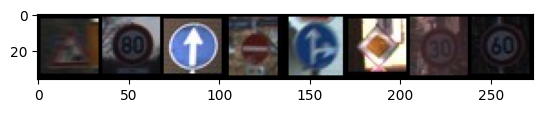

In [ ]:
x, y = next(iter(train_loader))
x = x[:8]
print('Input shape:', x.shape)
show(x)

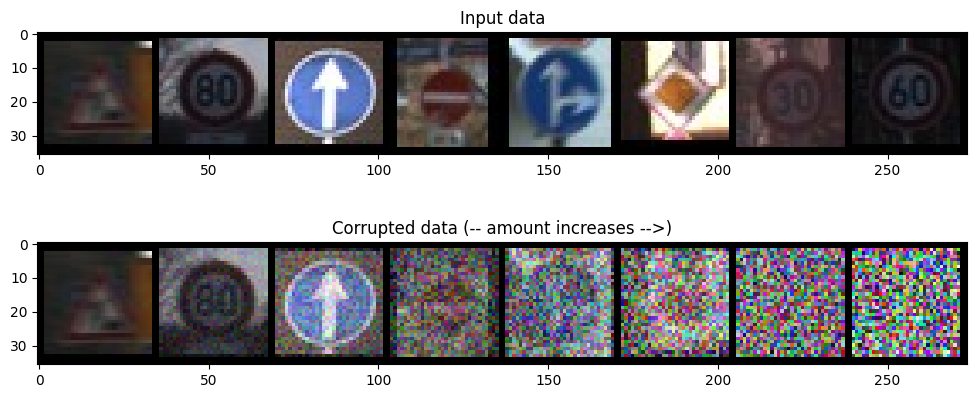

In [ ]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
show(x, axs[0])

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
show(noised_x, axs[1])

### Struktura sieci

In [ ]:
class BasicUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = nn.ModuleList([
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.Conv2d(512, 512, kernel_size=3, padding=1)
        ])
        self.up_layers = nn.ModuleList([
            nn.Conv2d(512 + 1, 512, kernel_size=3, padding=1),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, out_channels, kernel_size=3, padding=1)
        ])
        self.down_norms = nn.ModuleList([
            nn.GroupNorm(1, in_channels),
            nn.GroupNorm(4, 64),
            nn.GroupNorm(4, 64),
            nn.GroupNorm(8, 128),
            nn.GroupNorm(8, 128),
            nn.GroupNorm(16, 256),
            nn.GroupNorm(16, 256),
            nn.GroupNorm(32, 512)
        ])
        self.up_norms = nn.ModuleList([
            nn.GroupNorm(27, 512+1),
            nn.GroupNorm(32, 512),
            nn.GroupNorm(16, 256),
            nn.GroupNorm(16, 256),
            nn.GroupNorm(8, 128),
            nn.GroupNorm(8, 128),
            nn.GroupNorm(4, 64),
            nn.GroupNorm(4, 64)
        ])
        self.act = nn.SiLU() # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x, t):
        h = []
        for i, layer in enumerate(self.down_layers):
            # pre-norm: norm->act->conv
            x = layer(self.act(self.down_norms[i](x)))
            if i % 2 != 0 and i<len(self.down_layers)-1: # Dla co drugiej warstwy poza ostatnią
                h.append(x) # Zapisujemy "skip-connetions"
                x = self.downscale(x) # Zmniejszamy wymiarowość, i propagujemy do kolejnej warstwy
        t = t.repeat(1,x.size(2),x.size(3),1).permute(3,0,1,2)
        x = torch.cat([x,t],dim=1)
        for i, layer in enumerate(self.up_layers):
            if i % 2 == 0 and i>0: # Dla co drugiej warstwy poza pierwszą
                x = self.upscale(x) # Upscale
                x += h.pop() # Dodajemy zapisane skip-connection
            x = layer(self.act(self.up_norms[i](x)))
        return x

In [ ]:
net = BasicUNet(3, 3).to(device); net

BasicUNet(
  (down_layers): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (up_layers): ModuleList(
    (0): Conv2d(513, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Co

In [ ]:
sum([p.numel() for p in net.parameters()]) #Malutki model, najnowsze modele mają po kilka miliardów parametrów

9381515

### Trening

In [ ]:
last_epoch = 200
n_epochs = 500
save_every = 20

# Funkcja straty - zwykłe MSE
loss_fn = nn.MSELoss()

# Optymalizator
opt = torch.optim.Adam(net.parameters(), lr=4e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
scaler = amp.GradScaler(str(device))

# Wartości funkcji straty
train_losses = []
val_losses = []
best_loss = torch.inf
new_best = False

# The training loop
for epoch in range(last_epoch+1, last_epoch+n_epochs+1):
    # trening
    net.train()
    train_loss = 0
    for x, y in train_loader:
        opt.zero_grad()
        # Przygotowanie danych
        x = x.to(device)
        # Losowanie ilości dodanego szumu - może być krok, albo jak w tym przypadku ciągła wartość w %
        noise_amount = torch.rand(x.shape[0]).to(device) ** 2  # lekka preferencja mniejszych zaszumień, EV=0.33
        noisy_x = corrupt(x, noise_amount) # Zaszumiony przykład
        with amp.autocast(str(device)):
            # Predykcja oryginalnego - czystego obrazka
            pred = net(noisy_x, noise_amount)
            # Porównanie z oryginalnym obrazkiem
            loss = loss_fn(pred, x)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # walidacja
    net.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            noise_amount = torch.rand(x.shape[0]).to(device)
            noisy_x = corrupt(x, noise_amount)
            pred = net(noisy_x, noise_amount)
            loss = loss_fn(pred, x)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    print(f'Epoch {epoch}:\tTrain loss: {train_loss:f}\tVal loss: {val_loss:f}\tLR: {scheduler.get_last_lr()[0]:f}', end="")

    # TODO?: można spróbować sprawdzać FID co parę epok
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = deepcopy(net.state_dict())
        new_best = True
        print("\tNew best state!")
    else:
        print()
    if epoch % save_every == 0 and new_best:
        new_best = False
        torch.save(best_state, save_path+f'model_{epoch}.pth')
        print("Saved new best state.")
    scheduler.step()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 201:	Train loss: 0.004517	Val loss: 0.008344	LR: 0.000040	New best state!
Epoch 202:	Train loss: 0.004673	Val loss: 0.007938	LR: 0.000040	New best state!
Epoch 203:	Train loss: 0.004611	Val loss: 0.008000	LR: 0.000040
Epoch 204:	Train loss: 0.004589	Val loss: 0.008027	LR: 0.000040
Epoch 205:	Train loss: 0.004686	Val loss: 0.007909	LR: 0.000040	New best state!
Epoch 206:	Train loss: 0.004549	Val loss: 0.008195	LR: 0.000040
Epoch 207:	Train loss: 0.004439	Val loss: 0.007921	LR: 0.000040
Epoch 208:	Train loss: 0.004618	Val loss: 0.008159	LR: 0.000040
Epoch 209:	Train loss: 0.004532	Val loss: 0.007943	LR: 0.000040
Epoch 210:	Train loss: 0.004587	Val loss: 0.008325	LR: 0.000040
Epoch 211:	Train loss: 0.004730	Val loss: 0.007980	LR: 0.000040
Epoch 212:	Train loss: 0.004409	Val loss: 0.007664	LR: 0.000040	New best state!
Epoch 213:	Train loss: 0.004792	Val loss: 0.008341	LR: 0.000040
Epoch 214:	Train loss: 0.004644	Val loss: 0.007629	LR: 0.000040	New best state!
Epoch 215:	Train loss: 0

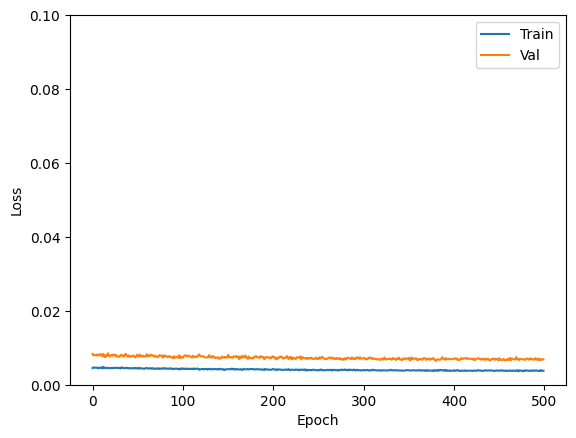

In [ ]:
# View the loss curve
plt.plot(train_losses)
plt.plot(val_losses)
plt.legend(['Train', 'Val'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 0.1);

In [ ]:
net.load_state_dict(torch.load(save_path+'model_421.pth'))

<All keys matched successfully>

### Odszumianie danych

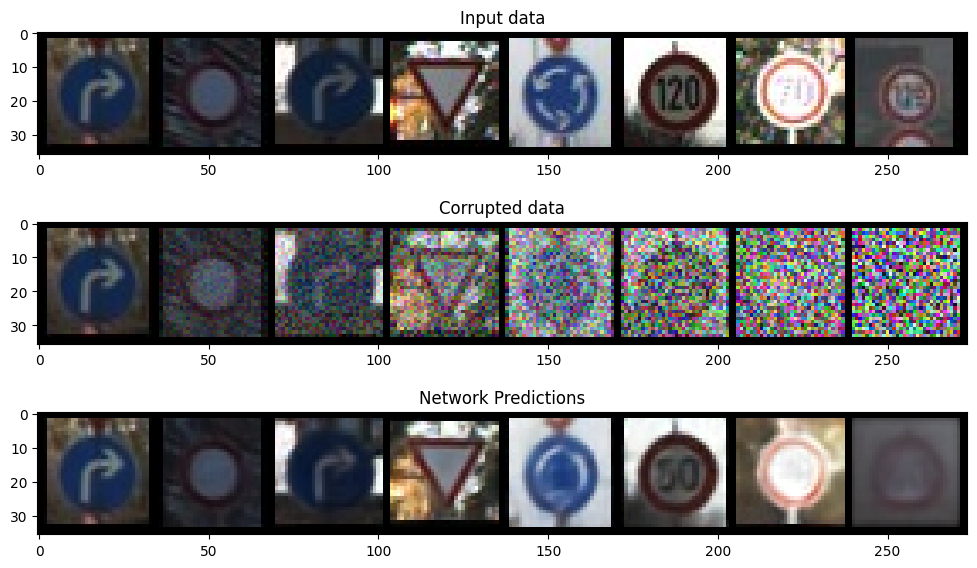

In [ ]:
# Fetch some data
x, y = next(iter(val_loader))
x = x[:8] # Only using the first 8 for easy plotting

# Corrupt with a range of amounts
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Get the model predictions
net.eval()
with torch.no_grad():
    preds = net(noised_x.to(device), amount.to(device)).detach().cpu()
    preds.clamp_(0, 1)

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title('Input data')
show(x, axs[0])
axs[1].set_title('Corrupted data')
show(noised_x, axs[1])
axs[2].set_title('Network Predictions')
show(preds, axs[2])

### Generacja

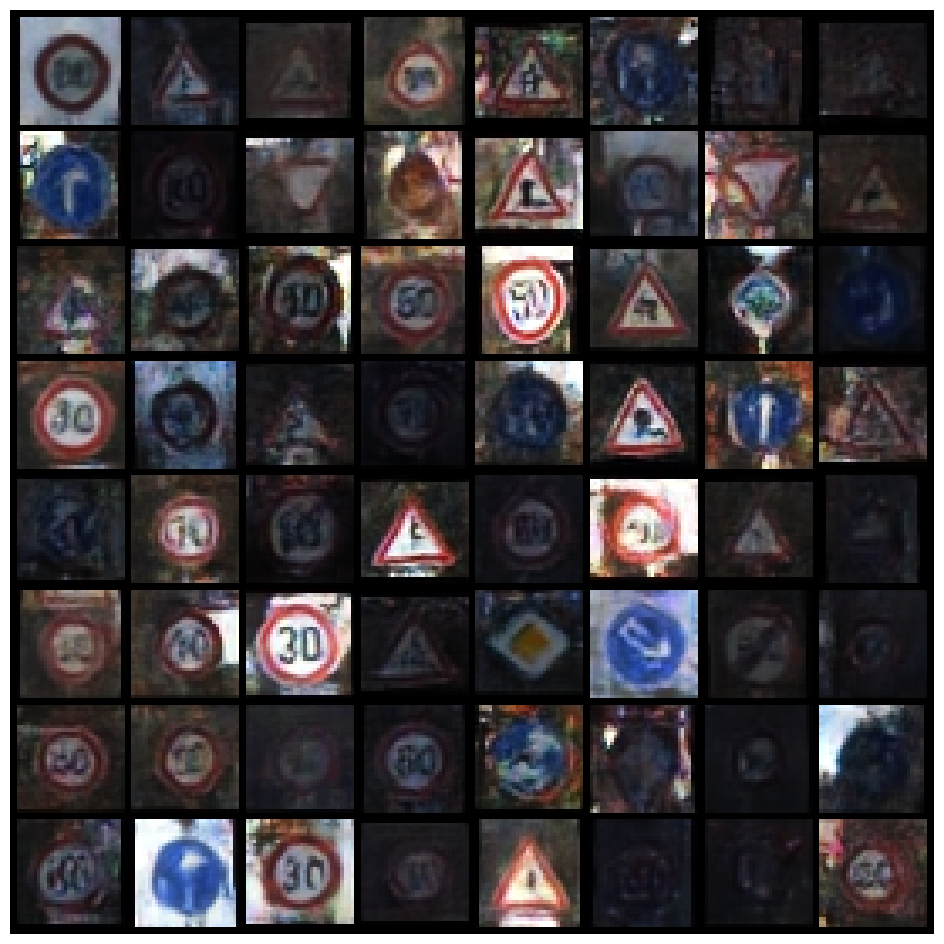

In [ ]:
n_steps = 100
x = torch.rand(64, 3, 32, 32).to(device)

net.eval()
for i in range(n_steps):
    t = torch.full(
        (x.size(0),),
        (n_steps - i) / n_steps,
        device=device
    )
    with torch.no_grad():
        pred = net(x, t)
    mix_factor = 1 / (n_steps - i)
    x = x * (1 - mix_factor) + pred * mix_factor
    x = x.clamp(0, 1)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
show(x.detach().cpu(), ax)
ax.axis('off');

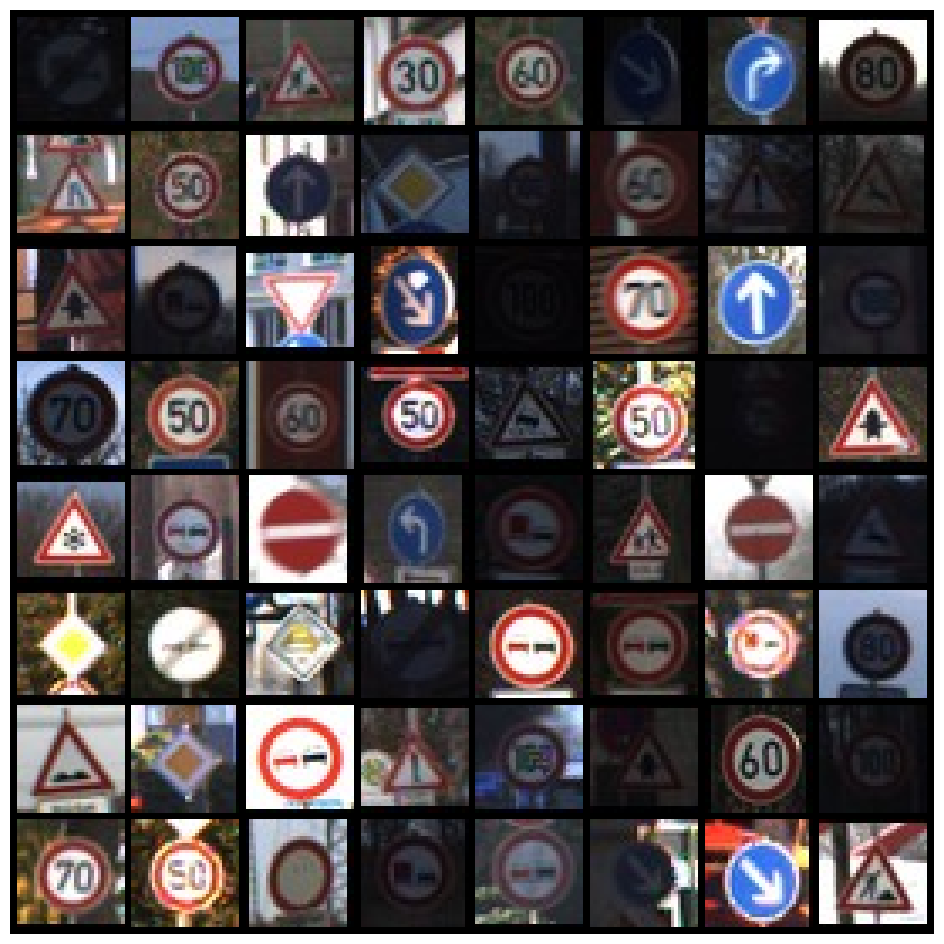

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
show(get_train_images(64).detach().cpu(), ax)
ax.axis('off');

## Generowanie danych i FID

In [ ]:
import torch

real_dir = "/content/real_images"
fake_dir = "/content/fake_images"

num_images = 1000
n_steps = 100

x_fake = torch.rand(num_images, 3, 32, 32).to(device)

net.eval()

for i in range(n_steps):

    t = torch.full(
        (x_fake.size(0),),
        (n_steps - i) / n_steps,
        device=device
    )

    with torch.no_grad():
        pred = net(x_fake, t)

    mix_factor = 1 / (n_steps - i)

    x_fake = x_fake * (1 - mix_factor) + pred * mix_factor
    x_fake = x_fake.clamp(0, 1)

# save generated images
torch.save(
    x_fake.cpu().detach(),
    save_path+"sroda_FijalkowskiZukowska_generated.pt"
)

print(x_fake.shape)

torch.Size([1000, 3, 32, 32])


In [ ]:
!pip install pytorch-fid

In [ ]:
loader = data.DataLoader(val_set, batch_size=1000, shuffle=True)
x_real, _ = next(iter(loader))
x_real = x_real.to(device)
print(x_real.shape)

torch.Size([1000, 3, 32, 32])


In [ ]:
import os
import shutil
from torchvision.utils import save_image

# clear old folders
for d in [real_dir, fake_dir]:

    if os.path.exists(d):
        shutil.rmtree(d)

    os.makedirs(d)

# save fake images
for i, img in enumerate(x_fake):

    save_image(
        img,
        f"{fake_dir}/{i:05d}.png"
    )

# save real images
for i, img in enumerate(x_real):

    save_image(
        img,
        f"{real_dir}/{i:05d}.png"
    )

print("Saved images.")

Saved images.


In [ ]:
!python -m pytorch_fid \
    /content/real_images \
    /content/fake_images

100% 20/20 [00:04<00:00,  4.11it/s]
100% 20/20 [00:04<00:00,  4.36it/s]
FID:  82.00532230046446
